# 01 · Elegir la herramienta correcta

Un agente financiero no debería buscar todo de la misma forma. Aquí probamos cuatro herramientas y una regla sencilla:

> **Cifra exacta → XBRL · Explicación → búsqueda · Sección completa → último recurso**

Los datos son locales; la primera búsqueda puede descargar el modelo de embeddings. No usamos un LLM ni hacemos llamadas de pago.

In [1]:
# Arranque reproducible desde la raíz o desde notebooks/
import pathlib, re, subprocess, sys, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import Markdown, display

RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").is_file())
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

from agente10k import datos
from agente10k.herramientas import (
    get_xbrl_fact, list_available, read_section, search_filings,
)

AZUL, VERDE, NARANJA, ROJO, GRIS = "#2563EB", "#16A34A", "#F59E0B", "#DC2626", "#64748B"
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## 1. La decisión en diez segundos

La herramienta correcta depende del tipo de pregunta, no de cuál parezca más potente.

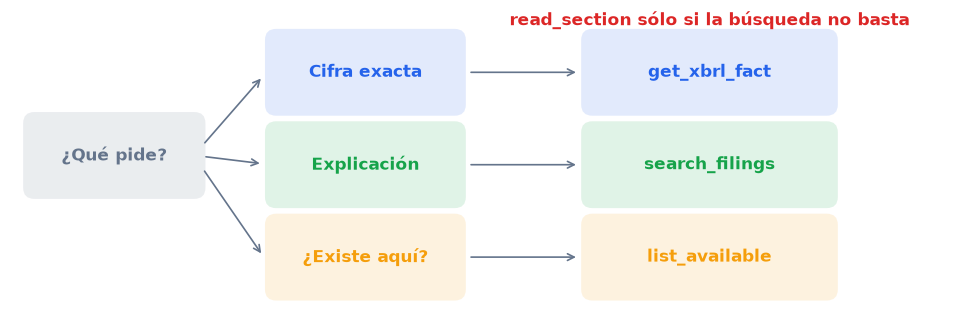

In [2]:
# Visual 1 · Ruta principal de una pregunta
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 3.2); ax.axis("off")

def caja(x, y, ancho, texto, color):
    ax.add_patch(FancyBboxPatch((x, y), ancho, .78, boxstyle="round,pad=.08,rounding_size=.12",
                                facecolor=color, edgecolor="none", alpha=.13))
    ax.text(x + ancho/2, y + .39, texto, ha="center", va="center", color=color, weight="bold")

caja(.2, 1.25, 1.8, "¿Qué pide?", GRIS)
caja(2.8, 2.15, 2.0, "Cifra exacta", AZUL)
caja(2.8, 1.15, 2.0, "Explicación", VERDE)
caja(2.8, .15, 2.0, "¿Existe aquí?", NARANJA)
caja(6.2, 2.15, 2.6, "get_xbrl_fact", AZUL)
caja(6.2, 1.15, 2.6, "search_filings", VERDE)
caja(6.2, .15, 2.6, "list_available", NARANJA)
for y in (2.54, 1.54, .54):
    ax.annotate("", xy=(6.1, y), xytext=(4.9, y), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, 2.5), xytext=(2.05, 1.75), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, 1.55), xytext=(2.05, 1.63), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.annotate("", xy=(2.7, .55), xytext=(2.05, 1.5), arrowprops={"arrowstyle": "->", "color": GRIS})
ax.text(7.5, 3.05, "read_section sólo si la búsqueda no basta", ha="center", color=ROJO, weight="bold")
plt.show()

### El corpus marca los límites

`list_available` evita preguntar por empresas o ejercicios que no existen. No devuelve cifras ni revela huecos concretos.

In [3]:
universo = list_available.invoke({})
empresas = [linea[2:] for linea in universo.splitlines() if linea.startswith("- ")]
display(Markdown("**Cobertura disponible**" + chr(10) * 2
                 + chr(10).join(f"- {e}" for e in empresas)))

**Cobertura disponible**

- AAPL (Apple Inc.): FY2024 (cierre 2024-09-28), FY2025 (cierre 2025-09-27)
- AMZN (AMAZON COM INC): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- GOOGL (Alphabet Inc.): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- META (Meta Platforms, Inc.): FY2024 (cierre 2024-12-31), FY2025 (cierre 2025-12-31)
- MSFT (MICROSOFT CORP): FY2024 (cierre 2024-06-30), FY2025 (cierre 2025-06-30)
- NVDA (NVIDIA CORP): FY2024 (cierre 2024-01-28), FY2025 (cierre 2025-01-26)

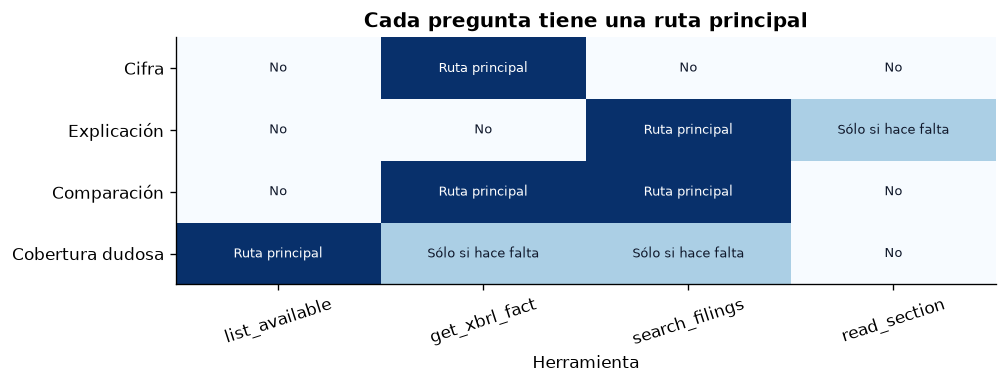

In [4]:
# Visual 2 · Qué herramienta encaja con cada pregunta
filas = ["Cifra", "Explicación", "Comparación", "Cobertura dudosa"]
columnas = ["list_available", "get_xbrl_fact", "search_filings", "read_section"]
matriz = np.array([[0, 3, 0, 0], [0, 0, 3, 1], [0, 3, 3, 0], [3, 1, 1, 0]])

fig, ax = plt.subplots(figsize=(8.5, 3.3))
imagen = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(4), columnas); ax.set_yticks(range(4), filas)
ax.tick_params(axis="x", rotation=18)
for i in range(4):
    for j in range(4):
        etiqueta = {0: "No", 1: "Sólo si hace falta", 3: "Ruta principal"}[matriz[i, j]]
        ax.text(j, i, etiqueta, ha="center", va="center",
                color="white" if matriz[i, j] == 3 else "#0F172A", fontsize=8)
ax.set_title("Cada pregunta tiene una ruta principal")
ax.set_xlabel("Herramienta")
plt.tight_layout(); plt.show()

## 2. XBRL: cifras exactas y huecos honestos

XBRL es la fuente autorizada para números. También distingue entre un dato ausente y un concepto escrito de otra forma.

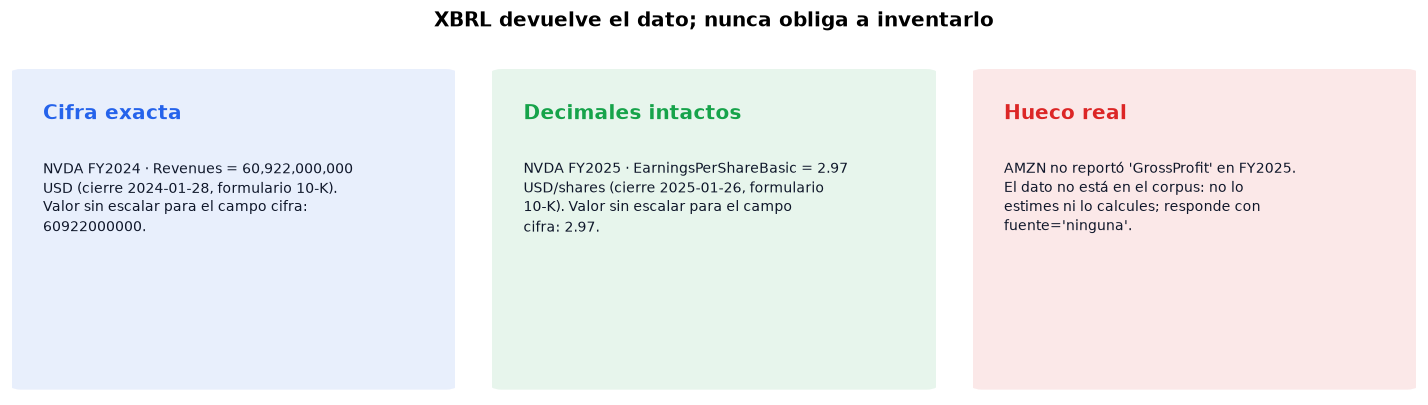

In [5]:
# Visual 3 · Tres comportamientos que debe dominar la herramienta
casos = [
    ("Cifra exacta", get_xbrl_fact.invoke({"ticker": "NVDA", "fiscal_year": 2024, "concept": "Revenues"}), AZUL),
    ("Decimales intactos", get_xbrl_fact.invoke({"ticker": "NVDA", "fiscal_year": 2025,
                                                  "concept": "EarningsPerShareBasic"}), VERDE),
    ("Hueco real", get_xbrl_fact.invoke({"ticker": "AMZN", "fiscal_year": 2025,
                                         "concept": "GrossProfit"}), ROJO),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (titulo, resultado, color) in zip(axes, casos):
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((.02, .04), .96, .9, boxstyle="round,pad=.03",
                                facecolor=color, edgecolor="none", alpha=.10))
    ax.text(.07, .82, titulo, transform=ax.transAxes, color=color, weight="bold", fontsize=12)
    ax.text(.07, .70, textwrap.fill(resultado, 42), transform=ax.transAxes,
            va="top", color="#0F172A", fontsize=8.5, linespacing=1.35)
fig.suptitle("XBRL devuelve el dato; nunca obliga a inventarlo", weight="bold")
plt.tight_layout(); plt.show()

## 3. Búsqueda: encontrar la explicación

Para texto usamos una consulta breve en inglés y dejamos empresa, ejercicio e item como filtros. El baseline compara embeddings con FAISS; todavía no usa BM25, RRF ni reescritura.

C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Usuario\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2485.52it/s]

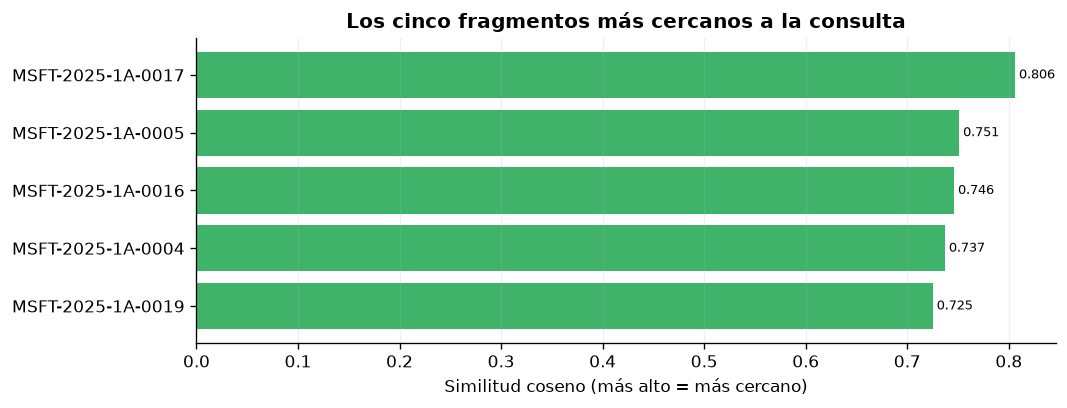

,chunk_id,similitud,vista_previa
0,MSFT-2025-1A-0017,0.806,"of operations. Issues in the development, depl..."
1,MSFT-2025-1A-0005,0.751,RISKS RELATING TO THE EVOLUTION OF OUR BUSINES...
2,MSFT-2025-1A-0016,0.746,Other digital safety abuses Our consumer servi...
3,MSFT-2025-1A-0004,0.737,"and sales incentives, which could adversely af..."
4,MSFT-2025-1A-0019,0.725,"to meet the evolving needs of our customers, p..."


In [6]:
# Una llamada real a la herramienta; mostramos el ranking, no cinco bloques de texto.
respuesta = search_filings.invoke({
    "query": "risks related to artificial intelligence products",
    "ticker": "MSFT", "fiscal_year": 2025, "item": "1A", "k": 5,
})
bloques = respuesta.split(chr(10) * 2 + "---" + chr(10) * 2)
filas_ranking = []
for bloque in bloques:
    cabecera, _, texto = bloque.partition(chr(10))
    hallado = re.search(r"\[([^\]]+)\].*similitud (-?[0-9]+[.][0-9]+)", cabecera)
    if hallado:
        filas_ranking.append({"chunk_id": hallado.group(1), "similitud": float(hallado.group(2)),
                              "vista_previa": textwrap.shorten(" ".join(texto.split()), 120)})
ranking = pd.DataFrame(filas_ranking)
if ranking.empty:
    raise RuntimeError(respuesta)

# Visual 4 · Ranking denso
fig, ax = plt.subplots(figsize=(9, 3.5))
orden = ranking.sort_values("similitud")
ax.barh(orden["chunk_id"], orden["similitud"], color=VERDE, alpha=.82)
ax.set_title("Los cinco fragmentos más cercanos a la consulta")
ax.set_xlabel("Similitud coseno (más alto = más cercano)")
ax.grid(axis="x", alpha=.2)
for y, valor in enumerate(orden["similitud"]):
    ax.text(valor, y, f" {valor:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()
display(ranking[["chunk_id", "similitud", "vista_previa"]])

## 4. Leer una sección completa cuesta mucho más

`read_section` conserva todo el contexto, pero puede añadir decenas de miles de tokens. Por eso comprobamos sólo su cabecera y no imprimimos el contenido.

**Cabecera devuelta:** `[AAPL FY2024 Item 7A · Quantitative and Qualitative Disclosures About Market Risk · 612 tokens]`

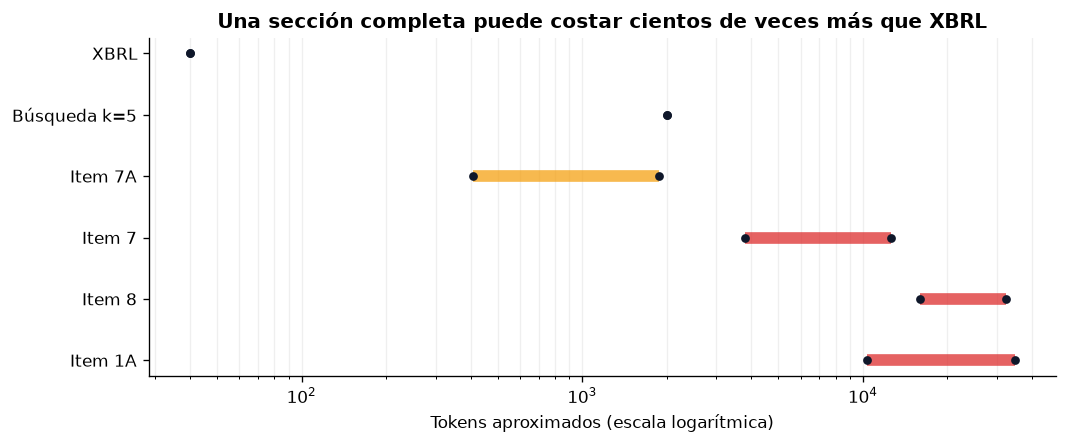

*XBRL y búsqueda son aproximaciones del enunciado; los rangos de secciones salen del corpus local.*

In [7]:
# Comprobación real sin volcar el texto completo
seccion_completa = read_section.invoke({"ticker": "AAPL", "fiscal_year": 2024, "item": "7A"})
display(Markdown(f"**Cabecera devuelta:** `{seccion_completa.splitlines()[0]}`"))

# Visual 5 · Coste relativo con rangos reales del corpus
secciones = datos.cargar_secciones()
rangos = secciones.groupby("item")["n_tokens"].agg(["min", "max"])
etiquetas = ["XBRL", "Búsqueda k=5", "Item 7A", "Item 7", "Item 8", "Item 1A"]
mins = np.array([40, 2000, rangos.loc["7A", "min"], rangos.loc["7", "min"],
                 rangos.loc["8", "min"], rangos.loc["1A", "min"]], dtype=float)
maxs = np.array([40, 2000, rangos.loc["7A", "max"], rangos.loc["7", "max"],
                 rangos.loc["8", "max"], rangos.loc["1A", "max"]], dtype=float)
y = np.arange(len(etiquetas))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hlines(y, mins, maxs, color=[AZUL, VERDE, NARANJA, ROJO, ROJO, ROJO], linewidth=7, alpha=.72)
ax.scatter(mins, y, color="#0F172A", s=18, zorder=3); ax.scatter(maxs, y, color="#0F172A", s=18, zorder=3)
ax.set_xscale("log"); ax.set_yticks(y, etiquetas); ax.invert_yaxis()
ax.set_xlabel("Tokens aproximados (escala logarítmica)")
ax.set_title("Una sección completa puede costar cientos de veces más que XBRL")
ax.grid(axis="x", alpha=.2, which="both")
plt.tight_layout(); plt.show()
display(Markdown("*XBRL y búsqueda son aproximaciones del enunciado; los rangos de secciones salen del corpus local.*"))

## 5. Pruebas sin LLM

Los contratos, los huecos, los decimales y el ranking se verifican sin gastar API. Si algo falla, esta celda detiene el notebook.

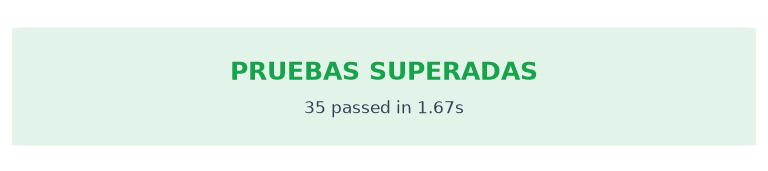

In [8]:
prueba = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_contratos.py", "tests/test_datos.py",
     "tests/test_herramientas.py", "tests/test_retrieval.py", "-q", "-p", "no:cacheprovider"],
    cwd=RAIZ, capture_output=True, text=True,
)

# Visual 6 · Estado de las pruebas
fig, ax = plt.subplots(figsize=(8, 1.6)); ax.axis("off")
color = VERDE if prueba.returncode == 0 else ROJO
estado = "PRUEBAS SUPERADAS" if prueba.returncode == 0 else "HAY PRUEBAS QUE REVISAR"
ultima = next((l for l in reversed(prueba.stdout.splitlines()) if "passed" in l or "failed" in l), "Sin resumen")
ax.add_patch(FancyBboxPatch((.02, .12), .96, .74, boxstyle="round,pad=.03",
                            facecolor=color, edgecolor="none", alpha=.12))
ax.text(.5, .58, estado, ha="center", va="center", color=color, weight="bold", fontsize=15)
ax.text(.5, .34, ultima, ha="center", va="center", color="#334155")
plt.show()
if prueba.returncode != 0:
    print(chr(10).join((prueba.stdout + prueba.stderr).splitlines()[-20:]))
    raise RuntimeError("La suite de pruebas no ha terminado correctamente")

## Idea final

- **Números:** `get_xbrl_fact`, incluso cuando el dato falta.
- **Texto y causas:** `search_filings`, siempre con `chunk_id` para citar.
- **Dudas de cobertura:** `list_available`.
- **Sección completa:** `read_section`, sólo como último recurso.

El siguiente paso será dar estas herramientas al agente. Mejorar el retrieval vendrá después y se medirá por separado.